Greyson Roy \
10\02\2026 \
Lab 6 - Spinning & Rolling Objects

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Part A — The Physical Pendulum

In [5]:
def rotate_step(theta, omega, torque, I, dt):
    alpha = torque / I
    omega += alpha*dt
    theta += omega*dt
    return theta, omega

In [ ]:
def simulate_pendulum(L, m, theta, omega, torque_func, I_func, dt, n_steps, g=1):

    t = 0
    I = I_func(L,m)
    torque = torque_func(L, m, g, theta)

    t_list = [t]
    theta_list = [theta]
    omega_list = [omega]
    alpha_list = [torque/I]

    for _ in range(n_steps):

        t += dt

        theta, omega = rotate_step(theta, omega, torque, I, dt)
        torque = torque_func(L, m, g, theta)

        t_list.append(t)
        theta_list.append(theta)
        omega_list.append(omega)
        alpha_list.append(torque/I)

    return t_list, theta_list, omega_list, alpha_list

def rod_pend_torque(L, m, g, theta):
    return -m*g*L/2*np.sin(theta)

def I_rod_end(L, m):
    return (1/3)*m*L**2

def small_approx(L, m, t, theta, I_func, g=1):
    I = I_func(L, m)
    O = np.sqrt(m*g*(L/2)/I)
    return theta*np.cos(O*t)

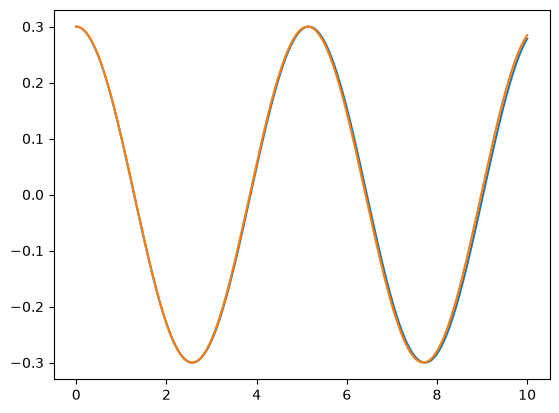

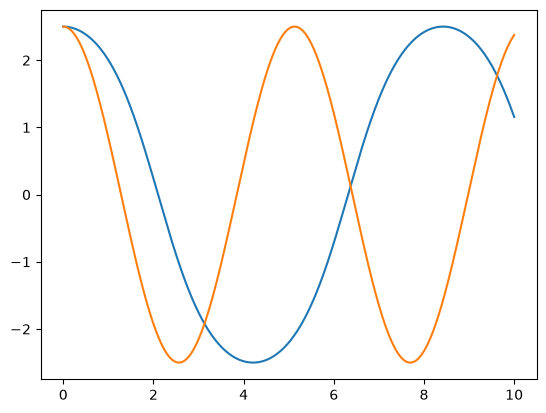

In [12]:
t_list, theta_list, omega_list, alpha_list = simulate_pendulum(1, 1, 0.3, 0, rod_pend_torque, I_rod_end, 0.01, 1000)
theta_approx = [small_approx(1, 1, t, 0.3, I_rod_end) for t in t_list]

plt.plot(t_list, theta_list)
plt.plot(t_list, theta_approx)
plt.show()

t_list, theta_list, omega_list, alpha_list = simulate_pendulum(1, 1, 2.5, 0, rod_pend_torque, I_rod_end, 0.01, 1000)
theta_approx = [small_approx(1, 1, t, 2.5, I_rod_end) for t in t_list]

plt.plot(t_list, theta_list)
plt.plot(t_list, theta_approx)
plt.show()

Part B - The Rolling Race

In [26]:
def rolling_accel(theta_incline, c, g=1):
    return g*np.sin(theta_incline) / (1+c)

def simulate_incline(accel_func, theta_incline, L, c, m, dt, g=1):

    a = accel_func(theta_incline, c, g=g)
    v = 0
    v_list = [v]
    x = L
    x_list = [x]
    t = 0
    t_list = [t]
    LKE = 0.5*m*v**2
    LKE_list = [LKE]
    RKE = 0.5*c*m*v**2 # solved from RKE=.5Iw^2 and c=I/(mR^2)
    RKE_list = [RKE]
    GPE = (x)*np.sin(theta_incline)
    GPE_list = [GPE]

    while x > 0:

        v += a*dt
        x -= v*dt
        t += dt
        LKE = 0.5*m*v**2
        RKE = 0.5*c*m*v**2
        GPE = (x)*np.sin(theta_incline)
        v_list.append(v)
        x_list.append(x)
        t_list.append(t)
        LKE_list.append(LKE)
        RKE_list.append(RKE)
        GPE_list.append(GPE)

    return t_list, v_list, x_list, LKE_list, RKE_list, GPE_list

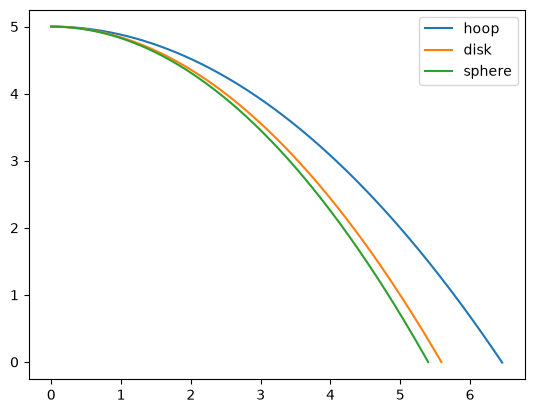

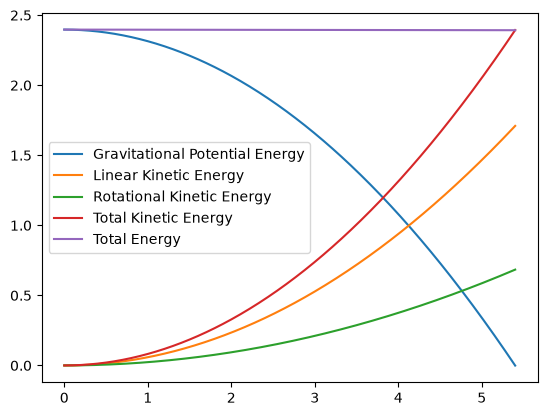

In [ ]:
for roller in [(1, 'hoop'), (0.5, 'disk'), (0.4, 'sphere')]:
    t, v, x, lke, rke, gpe = simulate_incline(rolling_accel, 0.5, 5, roller[0], 1, 0.01)
    plt.plot(t, x, label=roller[1])
plt.legend()
plt.show()

t, v, x, lke, rke, gpe = simulate_incline(rolling_accel, 0.5, 5, 0.4, 1, 0.01)
plt.plot(t, gpe, label='Gravitational Potential Energy')
plt.plot(t, lke, label='Linear Kinetic Energy')
plt.plot(t, rke, label='Rotational Kinetic Energy')
kpe = np.array(lke) + np.array(rke)
plt.plot(t, kpe, label='Total Kinetic Energy')
E = np.array(gpe) + kpe
plt.plot(t, E, label='Total Energy')
plt.legend()

Part C - Angular Momentum Conservation